In [5]:
import os 
import math
from functools import singledispatch
from collections.abc import Sequence, Sized, Iterable
from datetime import datetime
from typing import Optional, Union, List, Any, Generic
import pickle

import numpy as np
from numpy import typing as npt
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt

import pyarrow as pa
from pyarrow import compute as pc
 
from _unfolding_utils import pa_table, pa_concated_table, get_mean_stddev_tensors
from _histogram_utils import make_hist
from _plotting_utils import plot_ratios, plot_hist

In [9]:
emb_data_folder = "outputs/30May25-1147"
#output_folder=f"{emb_data_folder}/multifolding-{datetime.now().strftime("%d-%b-%y-%H-%M")}"
output_folder=f"{emb_data_folder}/multifolding-closure"
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

pth_bins = ["11", "15", "20", "25", "35", "45", "55", "infty"]
pth_bin_folders = [f"{emb_data_folder}/ptHat{pth_low}to{pth_high}" for pth_low, pth_high in zip(pth_bins[:-1], pth_bins[1:])]
n_pth_bins = len(pth_bin_folders)
matched_pth_label = list(range(1, n_pth_bins+1))
unmatched_pth_label = list(range(n_pth_bins+1, 2*n_pth_bins+1))
print(matched_pth_label, unmatched_pth_label, n_pth_bins)

gen_match_buffers, gen_match_table = pa_concated_table([f"{folder}/gen-matches.arrow" for folder in pth_bin_folders], label=matched_pth_label, label_key="stratify_labels")
gen_miss_buffers, gen_miss_table = pa_concated_table([f"{folder}/misses.arrow" for folder in pth_bin_folders], label=unmatched_pth_label, label_key="stratify_labels") 
reco_match_buffers, reco_match_table = pa_concated_table([f"{folder}/reco-matches.arrow" for folder in pth_bin_folders], label=matched_pth_label, label_key="stratify_labels")
reco_fake_buffers, reco_fake_table = pa_concated_table([f"{folder}/fakes.arrow" for folder in pth_bin_folders], label=unmatched_pth_label, label_key="stratify_labels")

do_use_gen_misses = False
if do_use_gen_misses:
    gen_table = pa.concat_tables([gen_match_table, gen_miss_table])
else:
    gen_table = gen_match_table

reco_table =pa.concat_tables([reco_match_table, reco_fake_table])
 
multifold_iter = 4

data_buffer, data_table = pa_table("outputs/jets-conPtMin0.2.arrow", label=0, label_key="stratify_labels") 
multifold_wt_list = np.load(f"{emb_data_folder}/multifolding_1/multifolded-wts-iter5.npz")
multifold_wt = multifold_wt_list[f"arr_{2*multifold_iter}"] 

data_sys_hcorr_buffer, data_sys_hcorr_table = pa_table("outputs/jets_conPtMin0.2_wTowerHadrCorrSys.arrow", label=0, label_key="stratify_labels")
multifold_sys_hcorr_wt_list = np.load(f"{emb_data_folder}/multifolding_w_had_corr/multifolded-wts-iter5.npz")
multifold_sys_hcorr_wt = multifold_sys_hcorr_wt_list[f"arr_{2*multifold_iter}"] 

data_sys_trkpt_buffer, data_sys_trkpt_table = pa_table("outputs/jets_conPtMin0.2_wTrackPtSys.arrow", label=0, label_key="stratify_labels")
multifold_sys_trkpt_wt_list = np.load(f"{emb_data_folder}/multifolding_wsys_track_eff/multifolded-wts-iter5.npz")
multifold_sys_trkpt_wt = multifold_sys_trkpt_wt_list[f"arr_{2*multifold_iter}"] 

omniseq_data_table = pa.concat_tables([reco_match_table, reco_fake_table])
omniseq_wt_list = np.load(f"{emb_data_folder}/omnisequential_1/omniseq-wts-iter10.npz")
omniseq_iter = 9
omniseq_data_wt = omniseq_wt_list[f"arr_{2*omniseq_iter+1}"]
omniseq_data_table = omniseq_data_table.set_column(0, "weight", pa.array(omniseq_data_wt, pa.float32()))

omniseq_wt = omniseq_wt_list[f"arr_{2*omniseq_iter}"]
multifold_closure_wt_list = np.load(f"{emb_data_folder}/multifolding-closure/multifolded-wts-iter5.npz")
multifold_closure_wt = multifold_closure_wt_list[f"arr_{2*multifold_iter}"]
 
py8_buffer, py8_table = pa_table("outputs/pythia8.arrow", label=0, label_key="stratify_labels")
#print(data_table.take([0,1]))
#print(reco_match_table.take([0,1]))

n_data = len(data_table)

n_gen_matches = len(gen_match_table)
n_gen_misses = len(gen_miss_table) if gen_miss_table is not None else 0
n_reco_matches = len(reco_match_table)
n_reco_fakes = len(reco_fake_table) if reco_fake_table is not None else 0

assert n_gen_matches == n_reco_matches

n_matches = n_gen_matches 
n_gen = n_matches + n_gen_misses
n_reco = n_matches + n_reco_fakes

print("Number of matched gen jets, matched reco jets:", n_gen_matches, n_reco_matches, n_matches)
print("Number of missed gen jets, fake reco jets:", n_gen_misses, n_reco_fakes)
print("Number of data jets:", n_data)

plot_output_dir = "plot_output"
if not os.path.exists(plot_output_dir):
    os.makedirs(plot_output_dir)

jet_columns = [
     "pt",
     #"nef",
     "ch_ang_k1_b0.5",
     "ch_ang_k1_b1",
     "ch_ang_k1_b2",
     "ch_ang_k2_b0",
     #"leading_constit_pt",
     #"subleading_constit_pt",
     "hc_pt",
     "hc_ch_ang_k1_b0.5",
     "hc_ch_ang_k1_b1",
     "hc_ch_ang_k1_b2",
     "hc_ch_ang_k2_b0",
     ]
     
col_bins = None
with open(f"{emb_data_folder}/omnisequential_1/omniseq-bins10.pkl", "rb") as f:
    col_bins = pickle.load(f)
    col_bins["ch_ang_k1_b2"] = col_bins["ch_ang_k1_b2"][1:]
    #col_bins["ch_ang_k2_b0"] = col_bins["ch_ang_k2_b0"][:-3]
    #col_bins["hc_ch_ang_k2_b0"] = col_bins["hc_ch_ang_k2_b0"][:-3]
    col_bins["pt"] = col_bins["pt"][3:]
    col_bins["hc_pt"] = col_bins["hc_pt"][4:]
    
    
#mainly for ratio plots/incl vs hc profile
ang_columns = [
     "ch_ang_k1_b0.5",
     "ch_ang_k1_b1",
     "ch_ang_k1_b2",
     "ch_ang_k2_b0",
     ]
     
ang_extra_labels = ["LHA", "girth", "thrust", "ptd"]

ratio_ylim = [[0, 3], [0, 3], [0,3], [0, 2]]

pt_arr = gen_table["pt"].to_numpy()
pt_bin_edges = [15, 20, float("inf")]
pt_bin_masks = [(pt_arr > low)&(pt_arr < high) for low, high in zip(pt_bin_edges[:-1], pt_bin_edges[1:])]
pt_bin_labels =  [f"{low} < p_T < {high} GeV/c" if not math.isinf(high) else f"p_T > {low}" for low, high in zip(pt_bin_edges[:-1], pt_bin_edges[1:])]

fig_scale = 5


[1, 2, 3, 4, 5, 6, 7] [8, 9, 10, 11, 12, 13, 14] 7
Number of matched gen jets, matched reco jets: 2862964 2862964 2862964
Number of missed gen jets, fake reco jets: 11985390 79281
Number of data jets: 866655


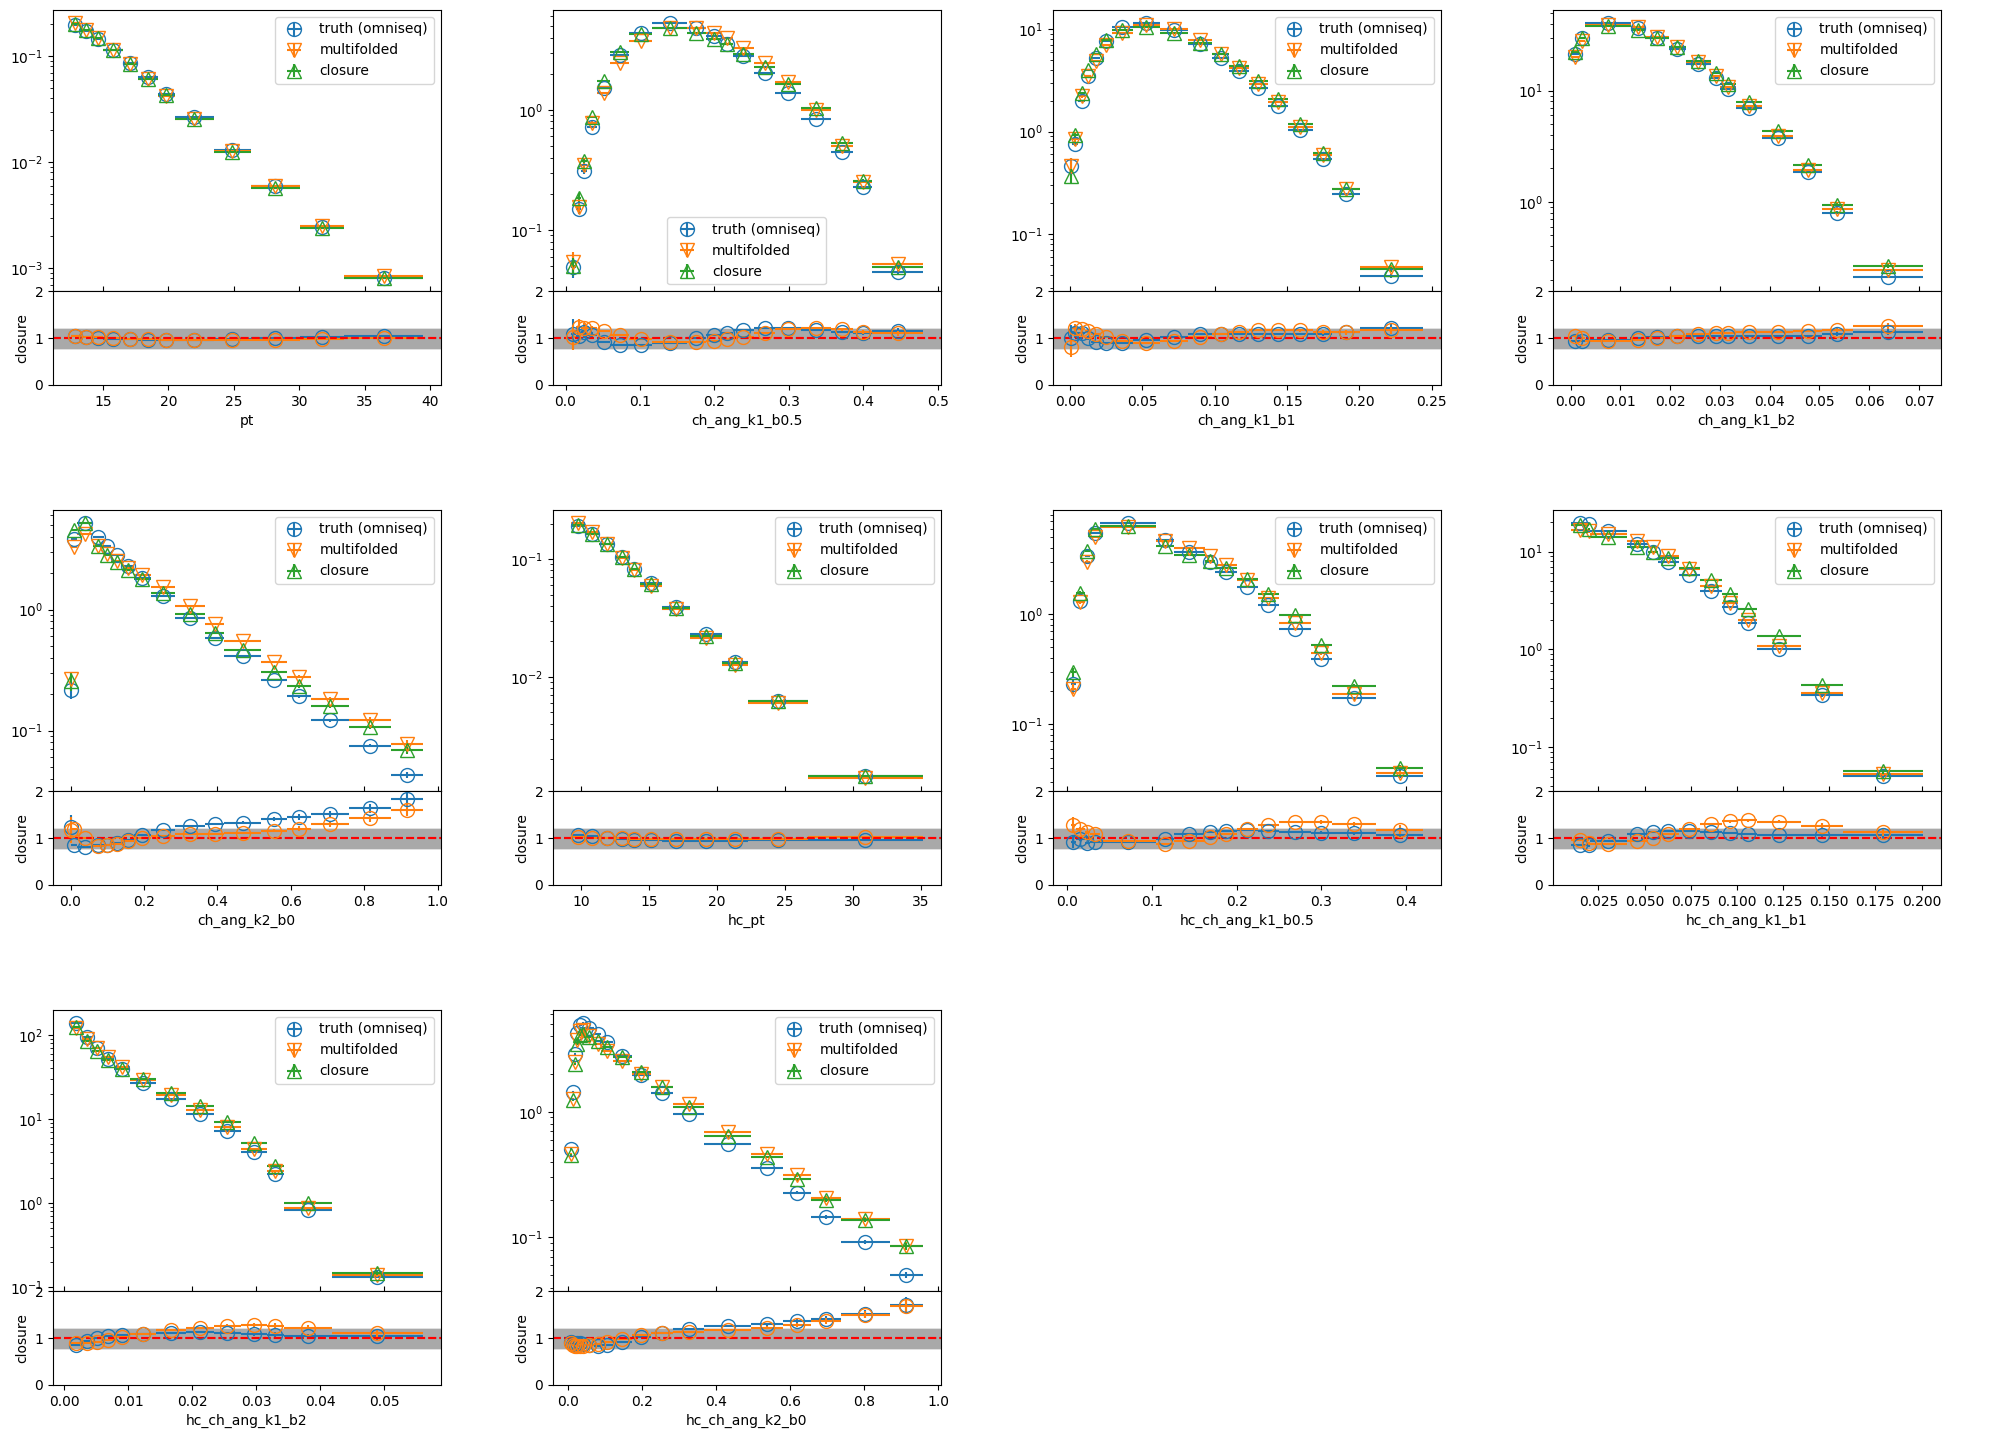

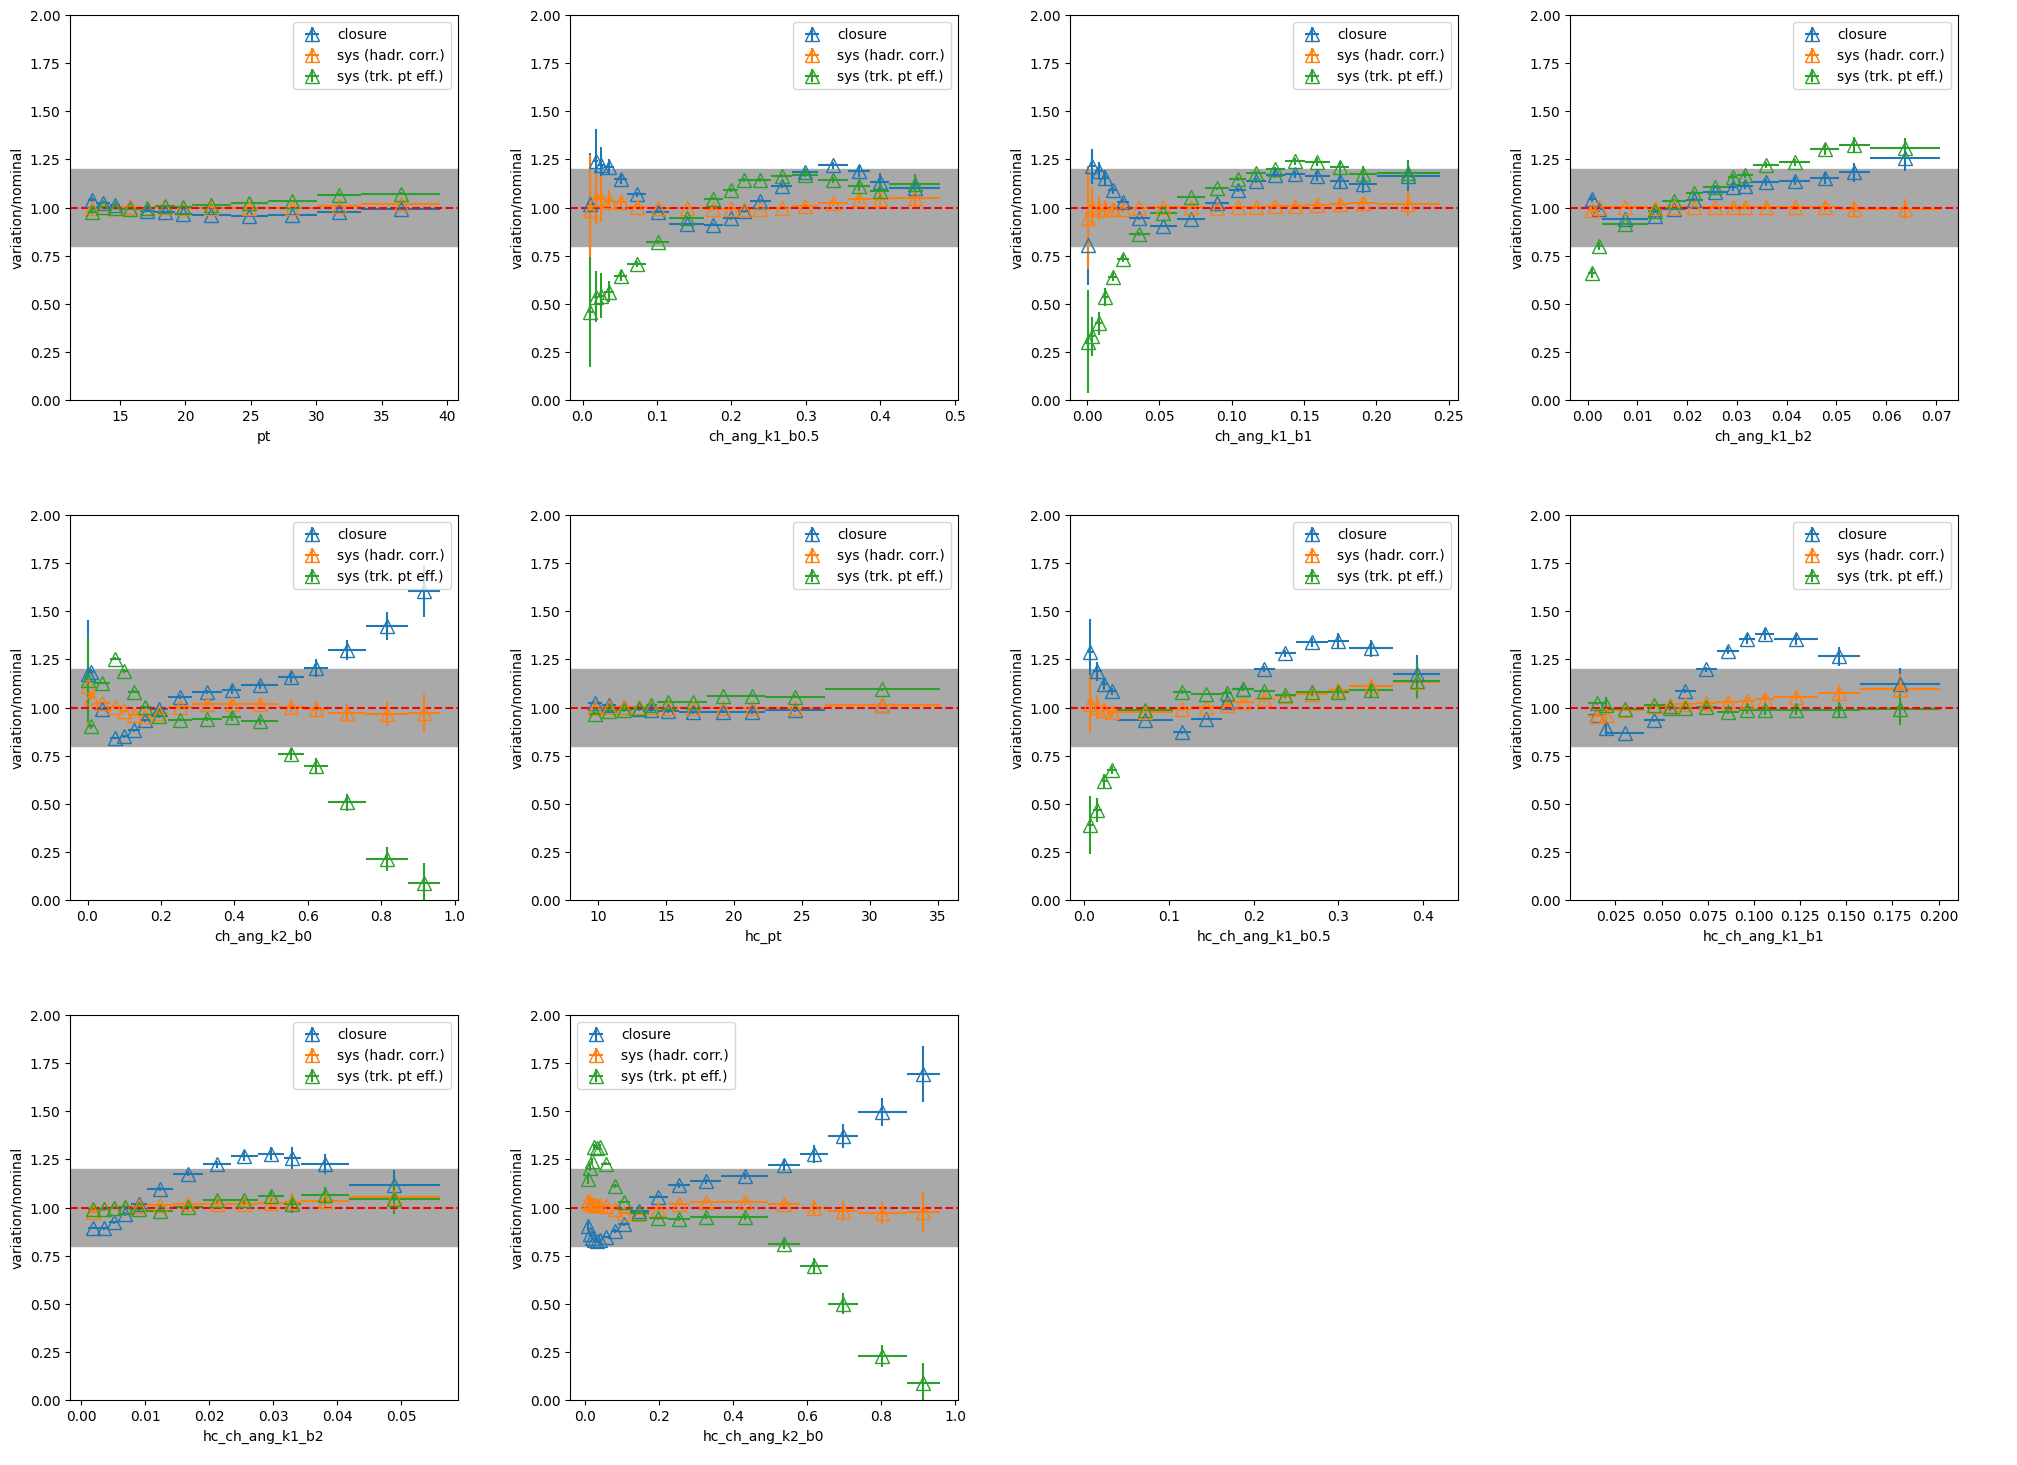

In [13]:
nrows = 3
ncols = int(np.ceil(len(jet_columns)/nrows))
fig_size = (ncols*fig_scale, nrows*fig_scale)

fig0 = plt.figure(figsize=fig_size)
subfigs0 = fig0.subfigures(nrows, ncols)

fig1 = plt.figure(figsize=fig_size)
subfigs1 = fig1.subfigures(nrows, ncols)

for ivar, var in enumerate(jet_columns):
    irow = int(np.floor(ivar/ncols))
    icol = ivar%ncols
    bins = col_bins[var] if col_bins is not None else None
    
    _, h_mlt, h_mlt_err = make_hist(gen_table[var].to_numpy(), weight=multifold_wt, bins=bins)
    _, h_mlt_sys_hcorr, h_mlt_sys_hcorr_err = make_hist(gen_table[var].to_numpy(), weight=multifold_sys_hcorr_wt, bins=bins)
    _, h_mlt_sys_trkpt, h_mlt_sys_trkpt_err = make_hist(gen_table[var].to_numpy(), weight=multifold_sys_trkpt_wt, bins=bins)
    _, h_mlt_clos, h_mlt_clos_err = make_hist(gen_table[var].to_numpy(), weight=multifold_closure_wt, bins=bins)
    _, h_seq, h_seq_err = make_hist(gen_table[var].to_numpy(), weight=omniseq_wt, bins=bins)
    
    h_ratio = h_mlt / h_seq
    h_ratio_err = h_ratio * np.sqrt((h_mlt_err / h_mlt) ** 2 + (h_seq_err / h_seq) ** 2)
    
    h_ratio_clos = h_mlt_clos / h_seq
    h_ratio_clos_err = h_ratio_clos * np.sqrt((h_mlt_clos_err / h_mlt_clos) ** 2 + (h_seq_err / h_seq) ** 2)

    h_ratio_sys_hcorr = h_mlt_sys_hcorr/h_mlt
    h_ratio_sys_hcorr_err = h_ratio_sys_hcorr * np.sqrt((h_mlt_err / h_mlt) ** 2 + (h_mlt_sys_hcorr_err / h_mlt_sys_hcorr) ** 2)
    
    h_ratio_sys_trkpt = h_mlt_sys_trkpt/h_mlt
    h_ratio_sys_trkpt_err = h_ratio_sys_trkpt * np.sqrt((h_mlt_err / h_mlt) ** 2 + (h_mlt_sys_trkpt_err / h_mlt_sys_trkpt) ** 2)

    ax0 = plot_ratios(subfigs0[irow, icol],
            bins,
            [h_mlt, h_mlt_clos],
            [h_seq],
            [[h_ratio], [h_ratio_clos]],
            [h_mlt_err, h_mlt_clos_err],
            [h_seq_err],
            [[h_ratio_err], [h_ratio_clos_err]],
            labels1=["multifolded", "closure"],
            labels2=["truth (omniseq)"],
            markers2=["o"],
            markers1=["v", "^"])
    ax0[1].set_xlabel(var)
    ax0[1].set_ylabel("closure")
    ax0[0].legend()

    ax1 = subfigs1[irow, icol].add_subplot()
    plot_hist(ax1, bins, h_ratio_clos, errors=h_ratio_clos_err, marker="^", fillstyle="none", linestyle="none", markersize=10, label="closure")
    plot_hist(ax1, bins, h_ratio_sys_hcorr, errors=h_ratio_sys_hcorr_err, marker="^", fillstyle="none", linestyle="none", markersize=10, label="sys (hadr. corr.)")
    plot_hist(ax1, bins, h_ratio_sys_trkpt, errors=h_ratio_sys_hcorr_err, marker="^", fillstyle="none", linestyle="none", markersize=10, label="sys (trk. pt eff.)")
    ax1.set_ylim(0, 2)
    ax1.axhline(y=1, color="red", linestyle="--")
    ax1.axhspan(0.8, 1.2, color="darkgrey")
    ax1.set_xlabel(var)
    ax1.set_ylabel("variation/nominal")
    ax1.legend()

fig0.savefig(f"{plot_output_dir}/mfold_seq_closure_ratio.pdf")
    

    


In [3]:
fig_scale = 5
nrows = 3
ncols = int(np.ceil(len(jet_columns)/nrows))
fig_size = (ncols*fig_scale, nrows*fig_scale)

fig0 = plt.figure(figsize=fig_size)
subfigs0 = fig0.subfigures(nrows, ncols)
for ivar, var in enumerate(jet_columns):
    irow = int(np.floor(ivar/ncols))
    icol = ivar%ncols
    bins = col_bins[var] if col_bins is not None else None
    
    _, h_mlt, h_mlt_err = make_hist(gen_table[var].to_numpy(), weight=mlt_wts[f"arr_{2*imlt}"], bins=bins)
    _, h_py6, h_py6_err = make_hist(gen_table[var].to_numpy(), weight=seq_wts[f"arr_0"], bins=bins)
    _, h_py8, h_py8_err = make_hist(py8_table[var].to_numpy(), bins=bins)
    
    h_ratio_py6 = h_mlt / h_py6
    h_ratio_py6_err = h_ratio_py6 * np.sqrt((h_mlt_err / h_mlt) ** 2 + (h_py6_err / h_py6) ** 2)

    h_ratio_py8 = h_mlt / h_py8
    h_ratio_py8_err = h_ratio_py8 * np.sqrt((h_mlt_err / h_mlt) ** 2 + (h_py8_err / h_py8) ** 2)
    
    axs = plot_ratios(subfigs0[irow, icol],
            bins,
            [h_py6, h_py8],
            [h_mlt],
            [[h_ratio_py6], [h_ratio_py8]],
            [h_py6_err, h_py8_err],
            [h_mlt_err],
            [[h_ratio_py6_err], [h_ratio_py8_err]],
            labels1=["pythia6", "pythia8"],
            labels2=["multifolded"],
            markers1=["^", "^"],
            markers2=["v"])
    axs[1].set_xlabel(var)
    axs[1].set_ylabel("mfold/mc")
    axs[0].legend()
fig0.savefig(f"{plot_output_dir}/mfold_mc_ratio.pdf")
 

NameError: name 'jet_columns' is not defined

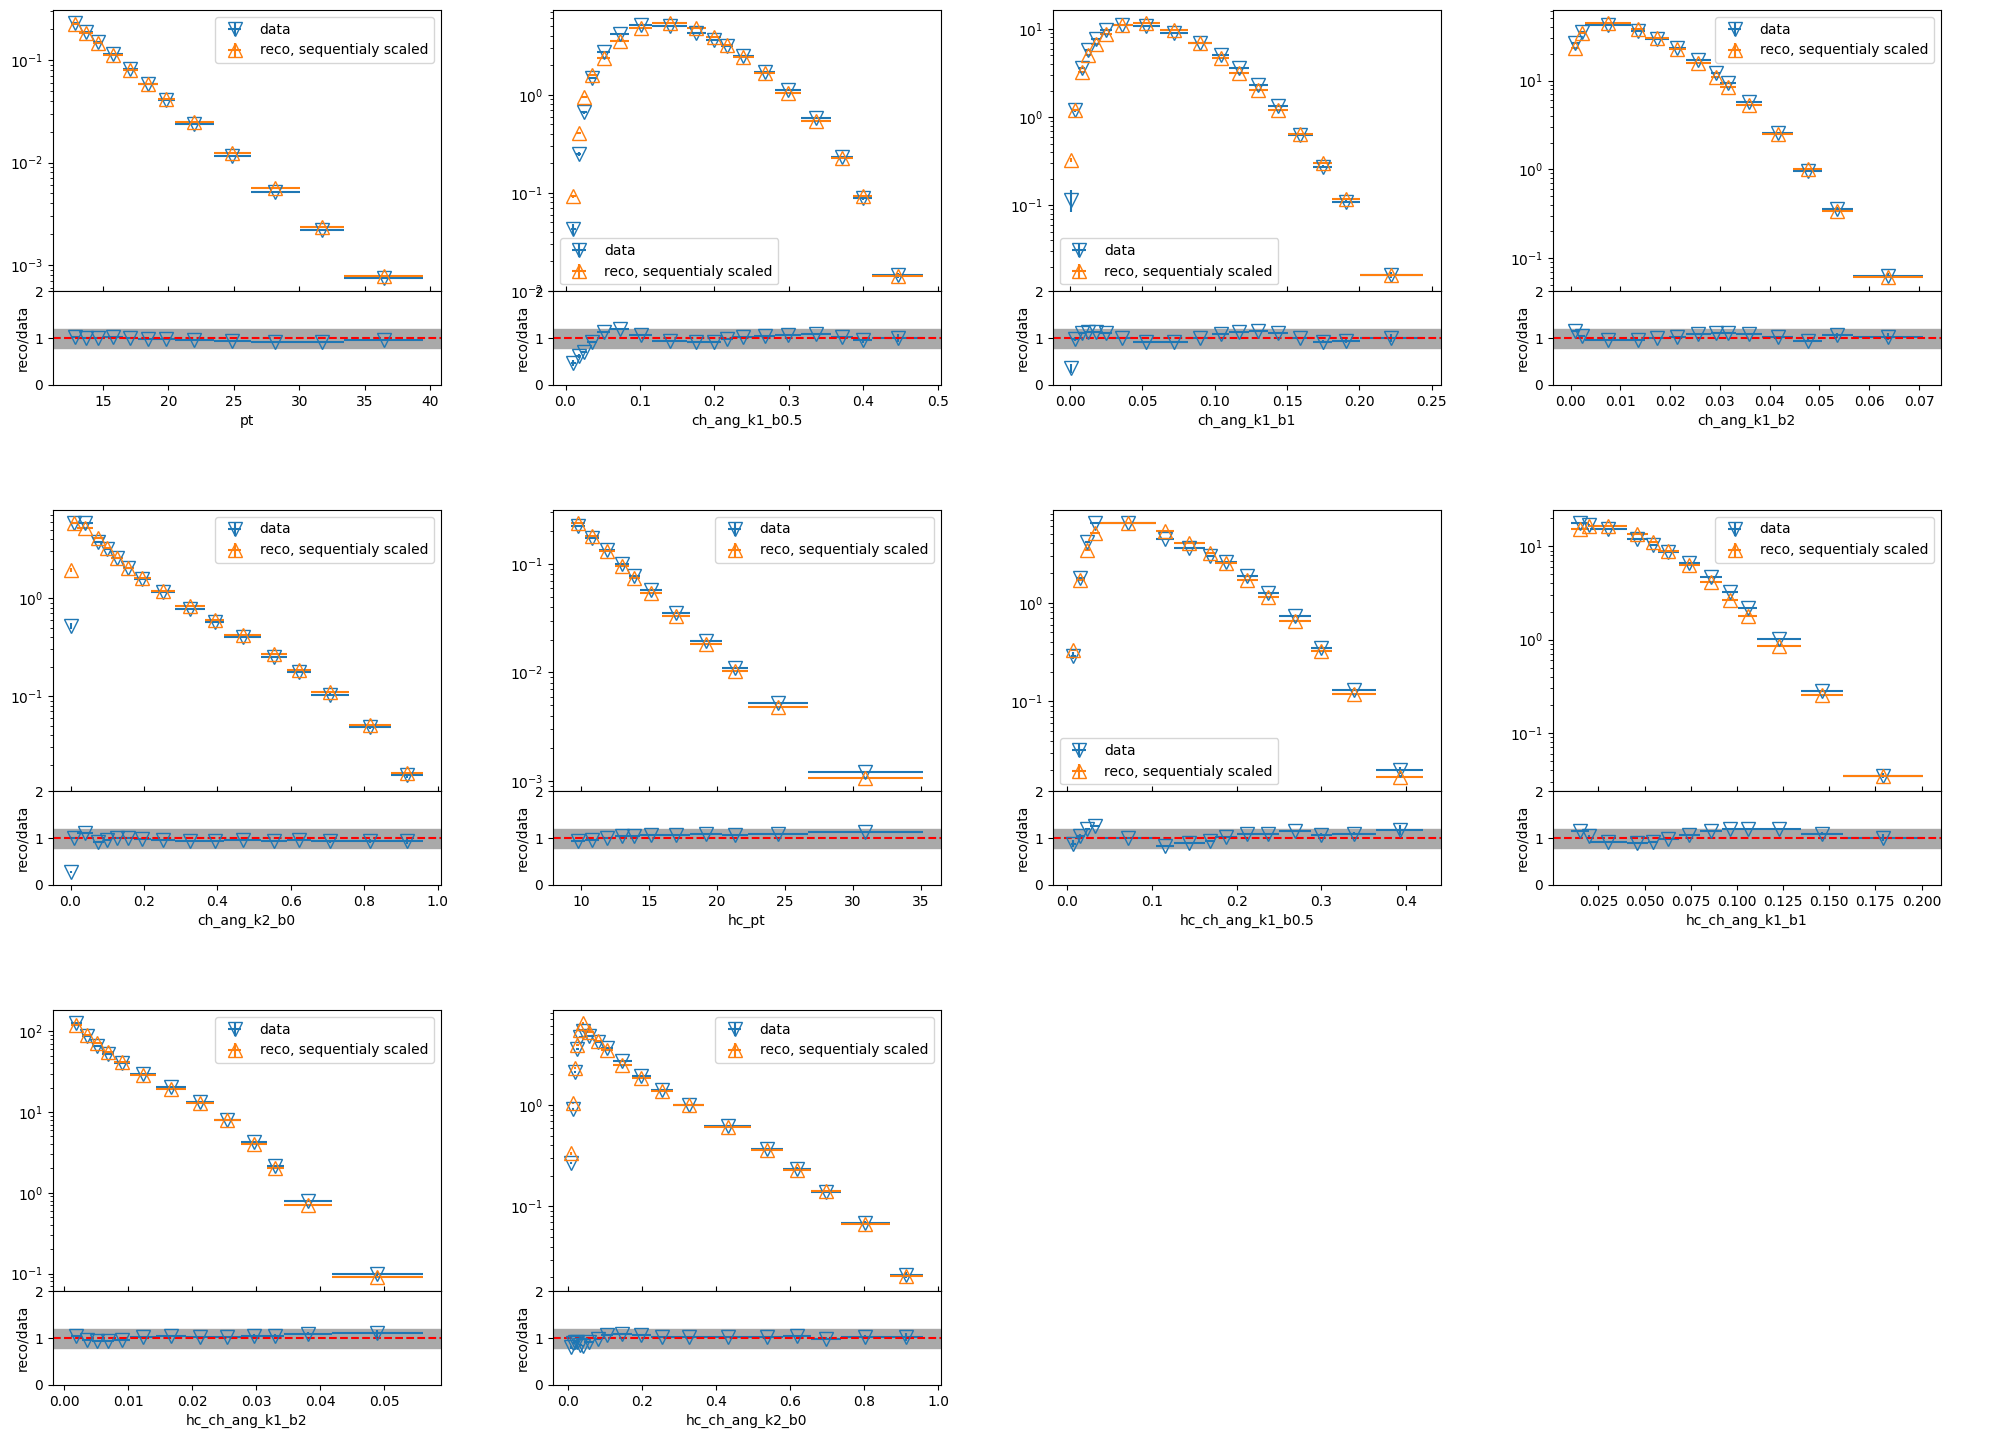

In [8]:
fig1 = plt.figure(figsize=fig_size)
subfigs1 = fig1.subfigures(nrows, ncols)
for ivar, var in enumerate(jet_columns):
    irow = int(np.floor(ivar/ncols))
    icol = ivar%ncols
    bins = col_bins[var] if col_bins is not None else None
    
    _, h_data, h_data_err = make_hist(data_table[var].to_numpy(), bins=bins)
    _, h_reco, h_reco_err = make_hist(reco_table[var].to_numpy(), weight=seq_wts[f"arr_{2*iseq+1}"], bins=bins)
    
    h_ratio = h_reco / h_data
    h_ratio_err = h_ratio * np.sqrt((h_data_err / h_data) ** 2 + (h_reco_err / h_reco) ** 2)
    
    axs = plot_ratios(subfigs1[irow, icol],
            bins,
            [h_data],
            [h_reco],
            [[h_ratio]],
            [h_data_err],
            [h_reco_err],
            [[h_ratio_err]],
            labels1=["reco, sequentialy scaled"],
            labels2=["data"],
            markers1=["^"],
            markers2=["v"])
    axs[1].set_xlabel(var)
    axs[1].set_ylabel("reco/data")
    axs[0].legend()
fig1.savefig(f"{plot_output_dir}/data_reco_ratio.pdf")
    #print(len(gen_table), len(mlt_wts[f"arr_{2*imlt}"]), len(seq_wts[f"arr_{2*iseq}"]))
    
    #ax0[irow, icol].hist(gen_table[var].to_numpy(), weights=mlt_wts[f"arr_{2*imlt}"], density=True, bins=bins, label="multifolded", histtype="step")
    #ax0[irow, icol].hist(gen_table[var].to_numpy(), weights=seq_wts[f"arr_{2*iseq}"], density=True, bins=bins, label="omnisequential", histtype="step")
    #ax0[irow, icol].set_yscale("log")
    #ax0[irow, icol].legend()
 

/tmp/ipykernel_64698/2646769285.py:32: RuntimeWarning: invalid value encountered in divide
  h_ratio_err = h_ratio * np.sqrt((h_ang_err / h_ang) ** 2 + (h_hc_ang_err / h_hc_ang) ** 2)


/tmp/ipykernel_64698/2646769285.py:31: RuntimeWarning: invalid value encountered in divide
  h_ratio = h_hc_ang / h_ang


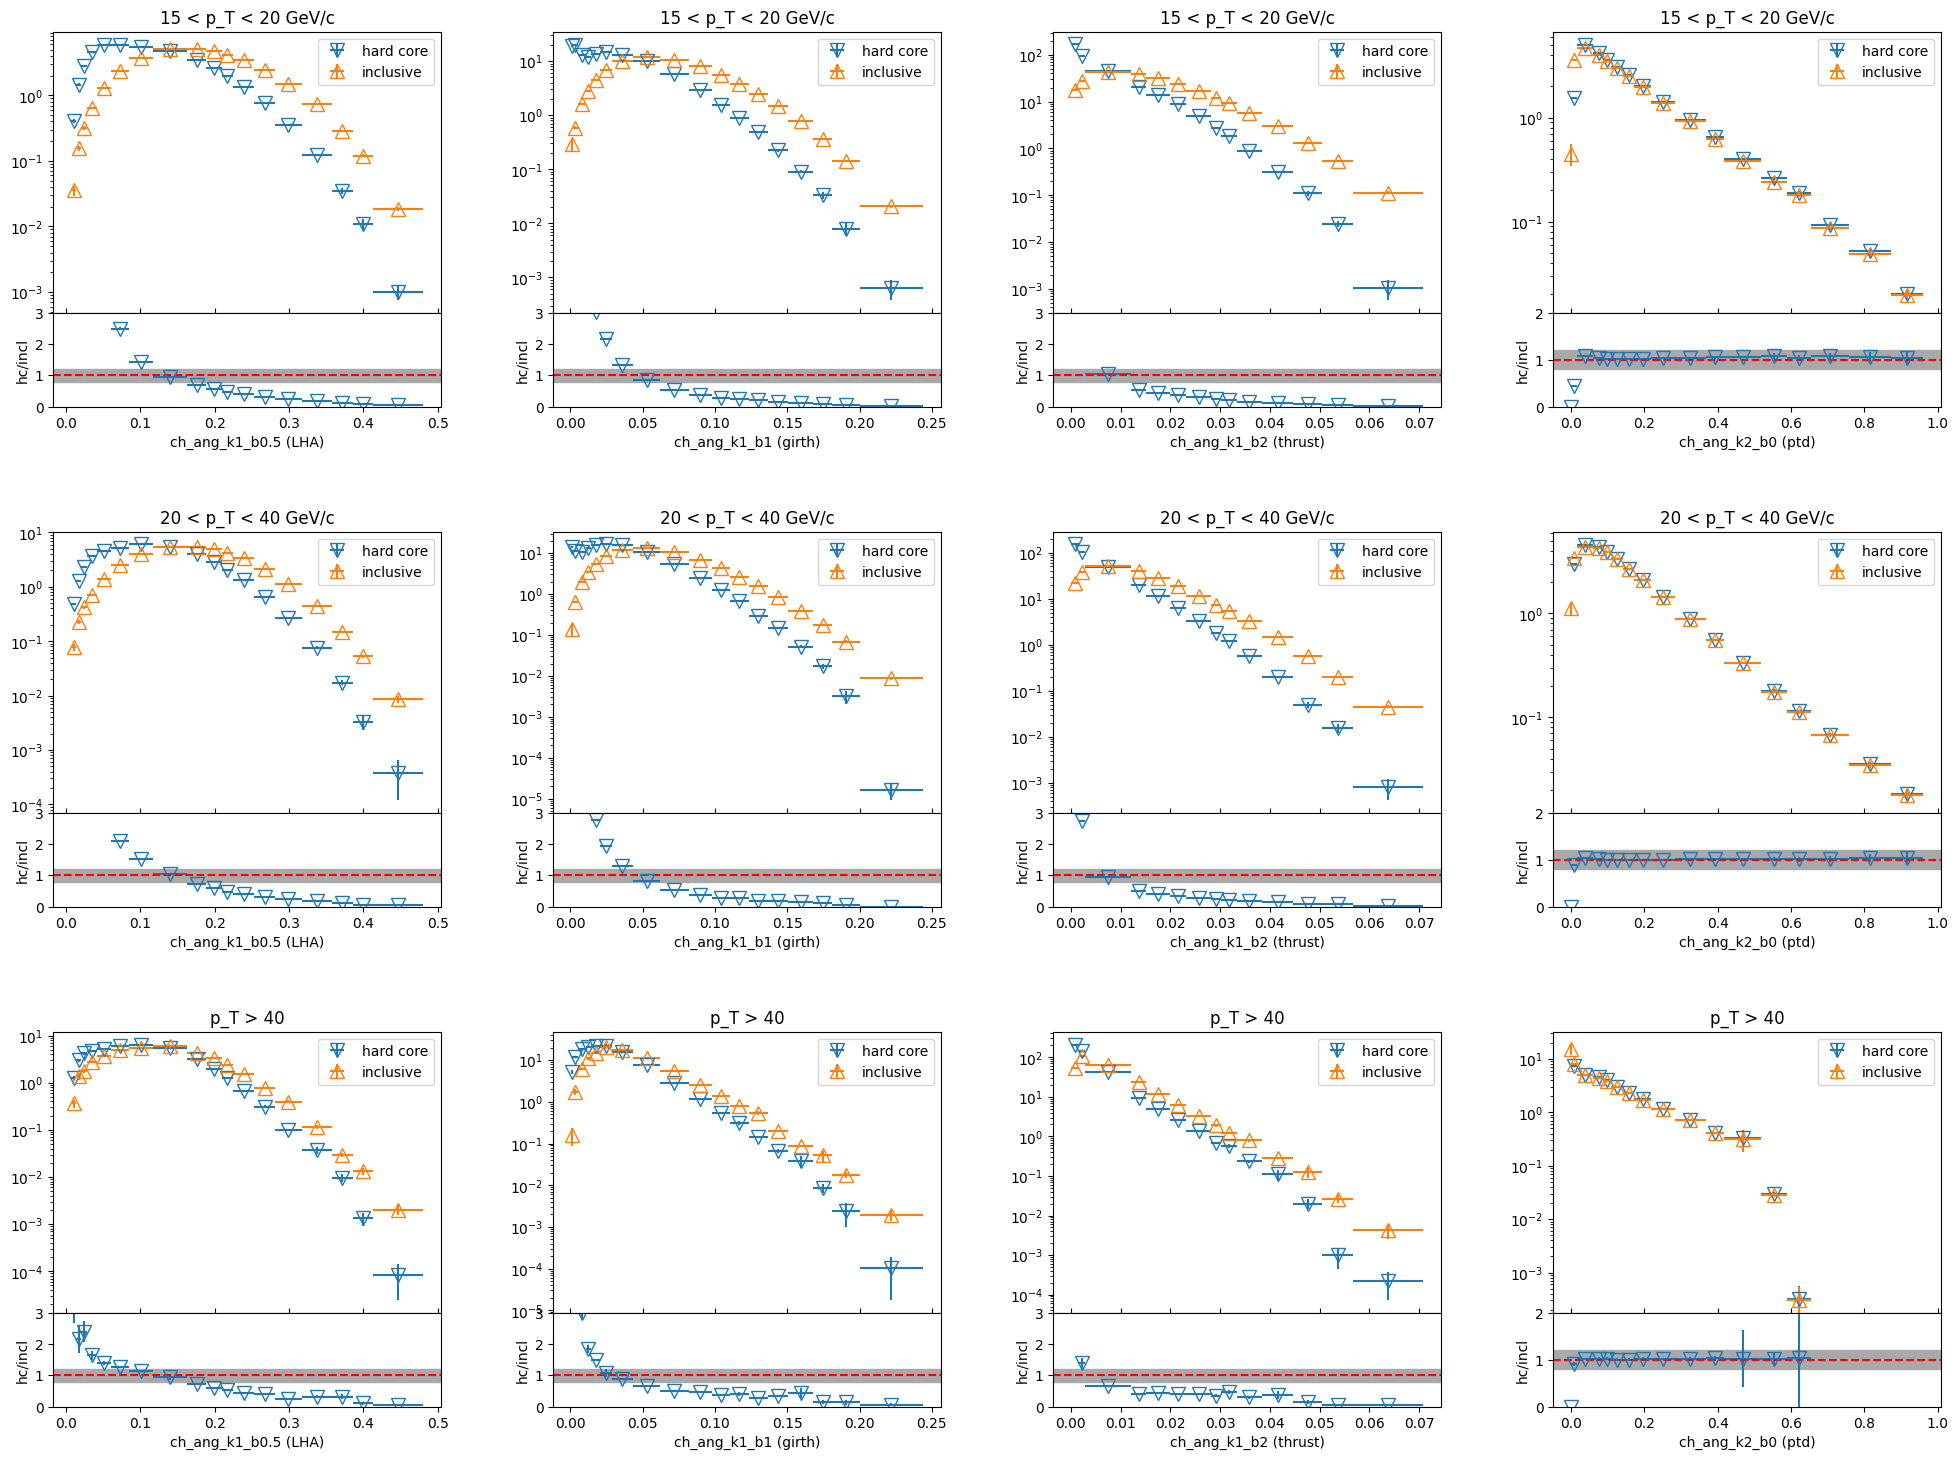

In [9]:
ncols = len(ang_columns)
nrows = len(pt_bin_labels)
fig = plt.figure(figsize=(fig_scale*ncols, nrows*fig_scale))
subfigs = fig.subfigures(nrows, ncols)
for ivar, var in enumerate(ang_columns):
    #irow = int(np.floor(ivar/ncols))
    icol = ivar%ncols
    bins = col_bins[var] if col_bins is not None else None
    axs = []
    for ipt_bin, pt_bin_mask in enumerate(pt_bin_masks):
        _, h_ang, h_ang_err = make_hist(gen_table[var].to_numpy()[pt_bin_mask], weight=mlt_wts[f"arr_{2*imlt}"][pt_bin_mask], bins=bins)
        _, h_hc_ang, h_hc_ang_err = make_hist(gen_table[f"hc_{var}"].to_numpy()[pt_bin_mask], weight=mlt_wts[f"arr_{2*imlt}"][pt_bin_mask], bins=bins)
        h_ratio = h_hc_ang / h_ang
        h_ratio_err = h_ratio * np.sqrt((h_ang_err / h_ang) ** 2 + (h_hc_ang_err / h_hc_ang) ** 2)

        axs.append(plot_ratios(
            subfigs[ipt_bin, icol], bins, 
            [h_ang], [h_hc_ang], [[h_ratio]],
            [h_ang_err], [h_hc_ang_err], [[h_ratio_err]],
            labels1=["inclusive"], markers1=["^"],
            labels2=["hard core"], markers2=["v"]
           ))
        axs[-1][1].set_xlabel(f"{var} ({ang_extra_labels[ivar]})")
        axs[-1][1].set_ylabel("hc/incl")
        axs[-1][0].set_title(pt_bin_labels[ipt_bin])
        axs[-1][1].set_ylim(*(ratio_ylim[ivar]))
        axs[-1][0].legend()
      
fig.savefig(f"{plot_output_dir}/incl_hcore_ratio.pdf")


/tmp/ipykernel_64698/2260154516.py:42: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "k-" (-> linestyle='-'). The keyword argument will take precedence.
  ax0s[ipt_bin, icol].plot(lims, lims, 'k-', linestyle="--", alpha=0.75, zorder=0)


/home/tanmaypani/star-workspace/jet-angularity-study/histograms.py:89: RuntimeWarning: invalid value encountered in sqrt
  hErry = np.sqrt(hVary)


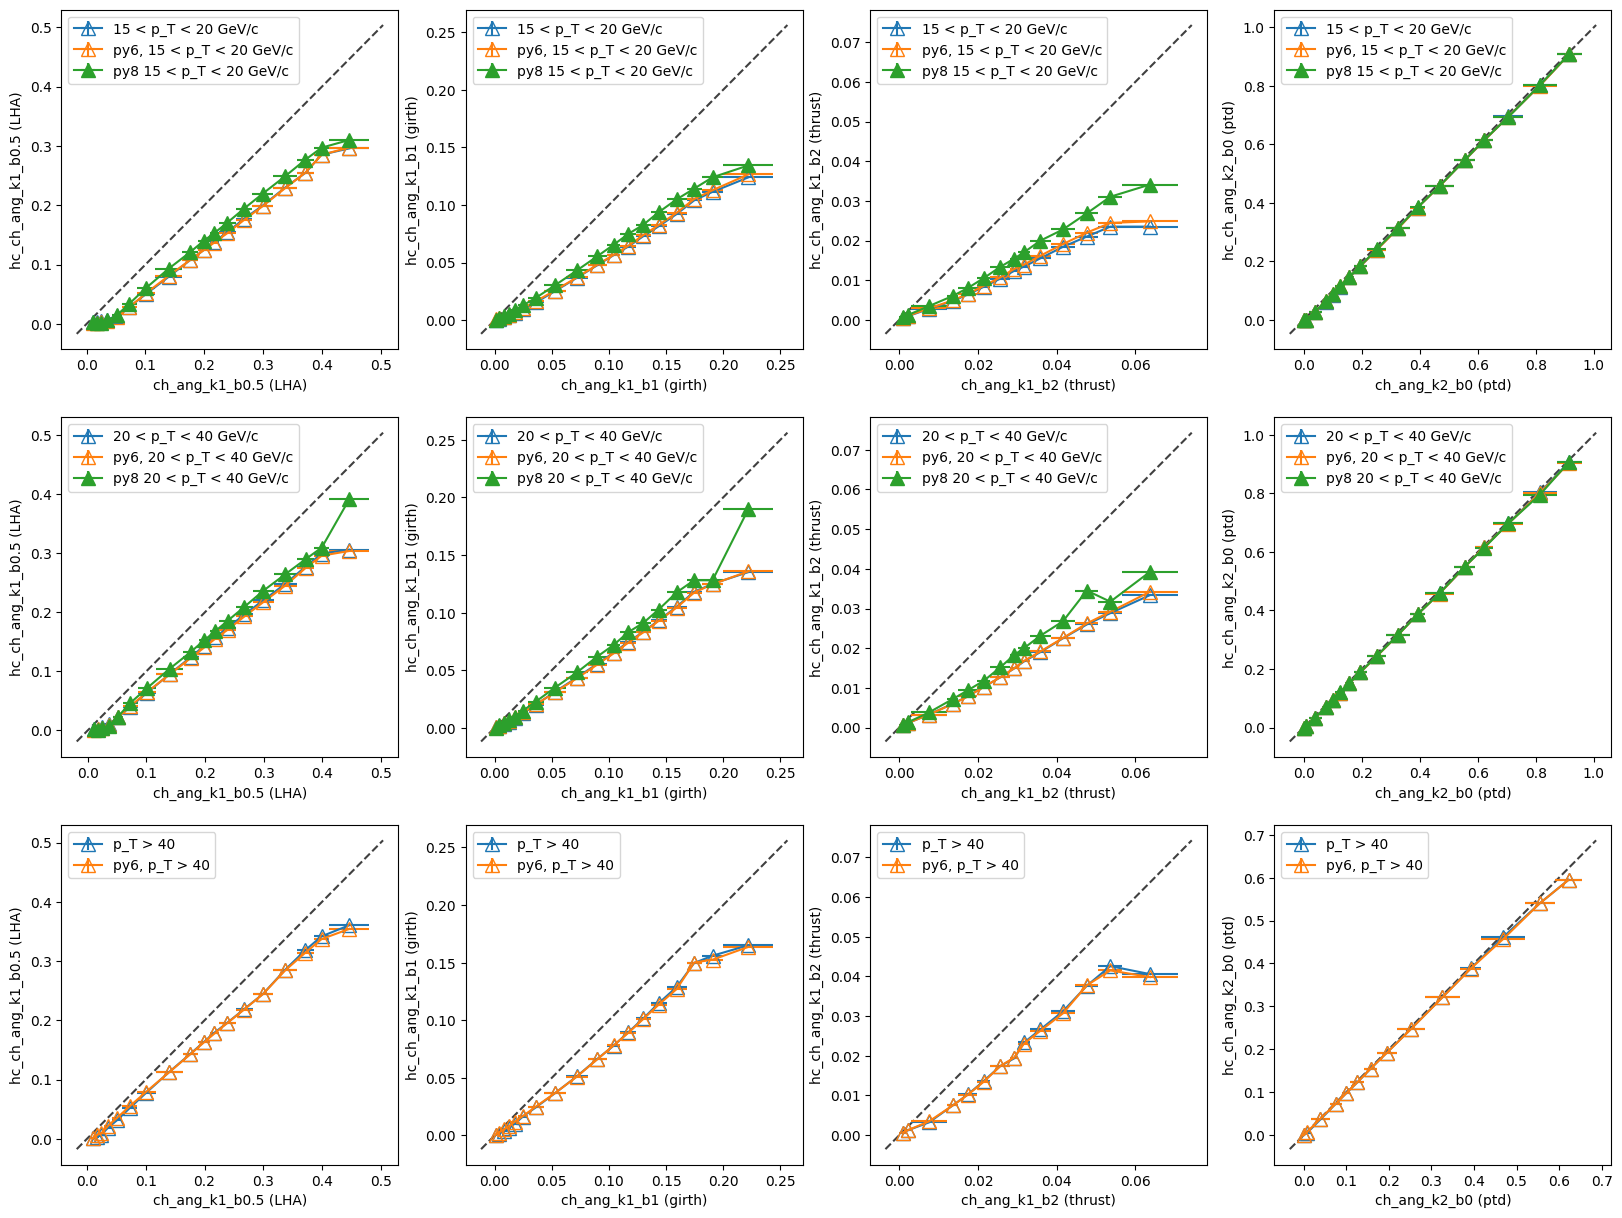

In [24]:
py8_pt_arr = py8_table["pt"].to_numpy()
py8_pt_bin_masks = [(py8_pt_arr > low)&(py8_pt_arr < high) for low, high in zip(pt_bin_edges[:-1], pt_bin_edges[1:])]

fig_scale = 5
ncols = len(ang_columns)
nrows = 3
fig0, ax0s = plt.subplots(nrows, ncols, figsize=(fig_scale*ncols, fig_scale*nrows))
for icol, var in enumerate(ang_columns):
    #irow = int(np.floor(ivar/ncols))
    #icol = ivar%ncols
    bins = col_bins[var] if col_bins is not None else 100
    hc_bins = col_bins[f"hc_{var}"] if col_bins is not None else 100
    
    wts = mlt_wts[f"arr_{2*imlt}"]
    wts_py6 = mlt_wts["arr_0"]
    arr_py6 = gen_table[var].to_numpy()
    hc_py6_arr = gen_table[f"hc_{var}"].to_numpy()
    
    arr_py8 = py8_table[var].to_numpy()
    hc_py8_arr = py8_table[f"hc_{var}"].to_numpy()

    x = (bins[1:]+bins[:-1])/2.0
    x_err = (bins[1:]-bins[:-1])/2.0
    
    for ipt_bin, (pt_bin_mask, py8_pt_bin_mask) in enumerate(zip(pt_bin_masks, py8_pt_bin_masks)):
        _, prof_mlt, prof_mlt_err = make_profile(arr_py6[pt_bin_mask], hc_py6_arr[pt_bin_mask], weight=wts[pt_bin_mask], bins=bins)
        _, prof_py6, prof_py6_err = make_profile(arr_py6[pt_bin_mask], hc_py6_arr[pt_bin_mask], weight=wts_py6[pt_bin_mask], bins=bins)
        _, prof_py8, prof_py8_err = make_profile(arr_py8[py8_pt_bin_mask], hc_py8_arr[py8_pt_bin_mask], bins=bins)
        if ipt_bin == 2 and var == "ch_ang_k2_b0":
            ax0s[ipt_bin, icol].errorbar(x[:-3], prof_mlt[:-3], xerr=x_err[:-3], yerr=0, marker="^", markersize=10, fillstyle="none", label=pt_bin_labels[ipt_bin])
            ax0s[ipt_bin, icol].errorbar(x[:-3], prof_py6[:-3], xerr=x_err[:-3], yerr=0, marker="^", markersize=10, fillstyle="none", label=f"py6, {pt_bin_labels[ipt_bin]}")
            if ipt_bin < 2:
                ax0s[ipt_bin, icol].errorbar(x[:-3], prof_py8[:-3], xerr=x_err[:-3], yerr=0, marker="^", markersize=10, label=f"py8, {pt_bin_labels[ipt_bin]}")
        else:
            ax0s[ipt_bin, icol].errorbar(x, prof_mlt, xerr=x_err, yerr=0, marker="^", markersize=10, fillstyle="none", label=pt_bin_labels[ipt_bin])
            ax0s[ipt_bin, icol].errorbar(x, prof_py6, xerr=x_err, yerr=0, marker="^", markersize=10, fillstyle="none", label=f"py6, {pt_bin_labels[ipt_bin]}")
            if ipt_bin < 2:
                ax0s[ipt_bin, icol].errorbar(x, prof_py8, xerr=x_err, yerr=0, marker="^", markersize=10, label=f"py8, {pt_bin_labels[ipt_bin]}")

        lims = [np.min([ax0s[ipt_bin, icol].get_xlim(), ax0s[ipt_bin, icol].get_ylim()]),  
                np.max([ax0s[ipt_bin, icol].get_xlim(), ax0s[ipt_bin, icol].get_ylim()])]
        ax0s[ipt_bin, icol].plot(lims, lims, 'k-', linestyle="--", alpha=0.75, zorder=0)
        ax0s[ipt_bin, icol].set_xlabel(f"{var} ({ang_extra_labels[icol]})")
        ax0s[ipt_bin, icol].set_ylabel(f"hc_{var} ({ang_extra_labels[icol]})")
        ax0s[ipt_bin, icol].legend()

fig0.savefig(f"{plot_output_dir}/incl_hcore_profile.pdf")


In [5]:
fig_scale = 5
ncols = len(ang_columns)
fig0, ax0s = plt.subplots(1, ncols, figsize=(fig_scale*ncols, fig_scale))
fig, axs = plt.subplots(nrows, ncols, figsize=(fig_scale*ncols, nrows*fig_scale))
for icol, var in enumerate(ang_columns):
    #irow = int(np.floor(ivar/ncols))
    #icol = ivar%ncols
    bins = col_bins[var] if col_bins is not None else 100
    hc_bins = col_bins[f"hc_{var}"] if col_bins is not None else 100
    
    wts = mlt_wts["arr_0"]
    arr = gen_table[var].to_numpy()
    hc_arr = gen_table[f"hc_{var}"].to_numpy()
    
    x = (bins[1:]+bins[:-1])/2.0
    x_err = (bins[1:]-bins[:-1])/2.0
    
    for ipt_bin, pt_bin_mask in enumerate(pt_bin_masks):
        _, prof, prof_err = make_profile(arr[pt_bin_mask], hc_arr[pt_bin_mask], weight=wts[pt_bin_mask], bins=bins)
        axs[ipt_bin, icol].hist2d(arr[pt_bin_mask], hc_arr[pt_bin_mask], weights=wts[pt_bin_mask], bins=[bins, hc_bins], density=True, norm="log")
        if ipt_bin == 2 and var == "ch_ang_k2_b0":
            ax0s[icol].errorbar(x[:-3], prof[:-3], xerr=x_err[:-3], yerr=0, marker="^", markersize=10, fillstyle="none", label=pt_bin_labels[ipt_bin])
            axs[ipt_bin, icol].errorbar(x[:-3], prof[:-3], xerr=x_err[:-3], yerr=prof_err[:-3], marker="^", markersize=10, color="red")
        else:
            ax0s[icol].errorbar(x, prof, xerr=x_err, yerr=0, marker="^", markersize=10, fillstyle="none", label=pt_bin_labels[ipt_bin])
            axs[ipt_bin, icol].errorbar(x, prof, xerr=x_err, yerr=prof_err, marker="^", markersize=10, color="red")
        axs[ipt_bin, icol].set_title(pt_bin_labels[ipt_bin])
        axs[ipt_bin, icol].set_xlabel(f"{var} ({ang_extra_labels[icol]})")
        axs[ipt_bin, icol].set_ylabel(f"hc_{var} ({ang_extra_labels[icol]})")

    lims = [np.min([ax0s[icol].get_xlim(), ax0s[icol].get_ylim()]),  np.max([ax0s[icol].get_xlim(), ax0s[icol].get_ylim()])]
    ax0s[icol].plot(lims, lims, 'k-', linestyle="--", alpha=0.75, zorder=0)
    ax0s[icol].set_xlabel(f"{var} ({ang_extra_labels[icol]})")
    ax0s[icol].set_ylabel(f"hc_{var} ({ang_extra_labels[icol]})")
    ax0s[icol].legend()

fig.savefig(f"{plot_output_dir}/incl_hcore_2d.pdf")
fig0.savefig(f"{plot_output_dir}/incl_hcore_profile.pdf")
